# Metrics Analysis

In this notebook I organize the results from `06-evaluation.ipynb` into cleaner tables and plots. The goal is not to recompute the explanations, but to understand how the existing metrics rank the nine XAI methods.

Main question: **do the objective metrics agree, or do they reward different properties of the explanations?**

In [1]:
from pathlib import Path
from zipfile import ZipFile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "artifacts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
RESULTS_DIR = PROJECT_ROOT / "docs" / "results"
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures" / "metrics-analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EVALUATION_PATH = ARTIFACTS_DIR / "generated-explanations" / "evaluation.json"
GENERATED_DIR = ARTIFACTS_DIR / "generated-explanations"

MODEL = "TANet"
DATASETS = ["EtriActivity3D", "Kinetics400"]

METHODS = [
    "3D-Kernel-SHAP-NEW",
    "3D-LIME-NEW",
    "3D-RISE-NEW",
    "3D-Sampled-Occl-Sens-NEW",
    "LV-LOCO-NEW",
    "LV-Univ-Pred-NEW",
    "SaliencyTubes",
    "AOSA",
    "GradCAM",
]

DISPLAY_NAMES = {
    "3D-Kernel-SHAP-NEW": "3D-Kernel-SHAP",
    "3D-LIME-NEW": "3D-LIME",
    "3D-RISE-NEW": "3D-RISE",
    "3D-Sampled-Occl-Sens-NEW": "3D-Sampled-Occl-Sens",
    "LV-LOCO-NEW": "LV-LOCO",
    "LV-Univ-Pred-NEW": "LV-Univ-Pred",
    "SaliencyTubes": "SaliencyTubes",
    "AOSA": "AOSA",
    "GradCAM": "GradCAM",
}

# Direction used when ranking methods. Lower rank is better.
METRIC_DIRECTIONS = {
    "deletion_auc": "lower",
    "insertion_auc": "higher",
    "avg_drop": "lower",
    "pointing_game": "higher",
    "iou50": "higher",
    "iou_value": "higher",
    "runtime_seconds": "lower",
    "bbox_energy_ratio": "higher",
    "temporal_consistency": "higher",
    "sparsity_80": "lower",
}

plt.rcParams.update({"font.size": 11})

## Load Results

The experiment I am analysing here uses one model (`TANet`), two datasets, 30 videos per dataset, and 9 explanation methods. The metric values are already saved in `evaluation.json`.

In [2]:
with EVALUATION_PATH.open("r", encoding="utf-8") as f:
    raw_results = json.load(f)

missing = []
for dataset in DATASETS:
    if dataset not in raw_results:
        missing.append(dataset)
        continue
    if MODEL not in raw_results[dataset]:
        missing.append(f"{dataset}/{MODEL}")
        continue
    for method in METHODS:
        if method not in raw_results[dataset][MODEL]:
            missing.append(f"{dataset}/{MODEL}/{method}")

if missing:
    raise ValueError(f"Missing expected results: {missing}")

scope = []
for dataset in DATASETS:
    first_method = raw_results[dataset][MODEL][METHODS[0]]
    n_videos = len(first_method["deletion"]["auc"])
    scope.append({"dataset": dataset, "model": MODEL, "methods": len(METHODS), "videos": n_videos})

scope_df = pd.DataFrame(scope)
scope_df

,dataset,model,methods,videos
0,EtriActivity3D,TANet,9,30
1,Kinetics400,TANet,9,30


## Tidy Metrics Table

I convert the nested JSON structure into a table with one row per video, dataset, and method. For the IoU metrics, I keep the same idea as the previous notebook: choose the threshold that gives the best average result for each method and dataset.

In [3]:
def _as_float(value):
    if value is None:
        return np.nan
    return float(value)


def best_threshold(metric_dict, key):
    """Choose the threshold that gives the highest average value."""
    threshold_means = {}
    for threshold, values in metric_dict[key].items():
        numeric_values = [_as_float(v) for v in values]
        threshold_means[threshold] = np.nanmean(numeric_values)
    return max(threshold_means, key=threshold_means.get)


def flatten_metrics(results):
    rows = []
    threshold_rows = []

    for dataset in DATASETS:
        for method in METHODS:
            method_results = results[dataset][MODEL][method]
            iou50_threshold = best_threshold(method_results["iou"], "th-50")
            iou_value_threshold = best_threshold(method_results["iou"], "value")

            threshold_rows.append({
                "dataset": dataset,
                "model": MODEL,
                "method": method,
                "method_display": DISPLAY_NAMES[method],
                "iou50_threshold": iou50_threshold,
                "iou_value_threshold": iou_value_threshold,
            })

            n_videos = len(method_results["deletion"]["auc"])
            for video_idx in range(n_videos):
                rows.append({
                    "dataset": dataset,
                    "model": MODEL,
                    "method": method,
                    "method_display": DISPLAY_NAMES[method],
                    "video_idx": video_idx,
                    "deletion_auc": _as_float(method_results["deletion"]["auc"][video_idx]),
                    "insertion_auc": _as_float(method_results["insertion"]["auc"][video_idx]),
                    "avg_drop": _as_float(method_results["drop"][video_idx]),
                    "pointing_game": float(bool(method_results["pointing-game"][video_idx])),
                    "iou50": float(bool(method_results["iou"]["th-50"][iou50_threshold][video_idx])),
                    "iou_value": _as_float(method_results["iou"]["value"][iou_value_threshold][video_idx]),
                })

    return pd.DataFrame(rows), pd.DataFrame(threshold_rows)


metrics_df, selected_iou_thresholds = flatten_metrics(raw_results)
metrics_df.to_csv(RESULTS_DIR / "metrics_per_video.csv", index=False)
selected_iou_thresholds.to_csv(RESULTS_DIR / "selected_iou_thresholds.csv", index=False)

metrics_df.head()

,dataset,model,method,method_display,video_idx,deletion_auc,insertion_auc,avg_drop,pointing_game,iou50,iou_value
0,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,0,0.032272,0.979946,81.433276,1.0,0.0,0.073712
1,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,1,0.028884,0.995008,16.392034,1.0,0.0,0.070977
2,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,2,0.027002,0.976799,63.213953,1.0,1.0,0.579722
3,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,3,0.013604,0.683879,44.272689,1.0,1.0,0.390767
4,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,4,0.130559,0.924136,27.182446,0.0,0.0,0.057879


## Runtime Table

The runtime values are stored as text files inside the generated artifacts. For `GradCAM`, the available timing file is the same one used for `SaliencyTubes`, so I keep that convention here.

In [4]:
# The file names are not fully consistent across methods, so I map them here.
def time_file_for_method(method):
    if method == "GradCAM":
        return "SaliencyTubes-time.txt"
    if method == "SaliencyTubes":
        return "SaliencyTubes-time.txt"
    if method == "AOSA":
        return "AOSA-time.txt"
    return f"{method}-time-16x112x112.txt"


def collect_runtime_rows():
    rows = []
    for dataset in DATASETS:
        labels_root = GENERATED_DIR / dataset / "data-labels" / MODEL
        for method in METHODS:
            filename = time_file_for_method(method)
            for time_path in labels_root.glob(f"*/*/{filename}"):
                video_name = time_path.parent.name
                video_class = time_path.parent.parent.name
                try:
                    value = float(time_path.read_text().strip())
                except ValueError:
                    value = np.nan
                rows.append({
                    "dataset": dataset,
                    "model": MODEL,
                    "method": method,
                    "method_display": DISPLAY_NAMES[method],
                    "video_class": video_class,
                    "video_name": video_name,
                    "runtime_seconds": value,
                })
    return pd.DataFrame(rows)


runtime_df = collect_runtime_rows()
runtime_df.to_csv(RESULTS_DIR / "runtime_per_video.csv", index=False)
runtime_df.groupby(["dataset", "method_display"])["runtime_seconds"].agg(["count", "mean", "std"]).round(3).head(12)

count     mean    std
dataset        method_display                             
EtriActivity3D 3D-Kernel-SHAP           30  449.150  2.005
               3D-LIME                  30  442.550  2.048
               3D-RISE                  30  440.134  2.354
               3D-Sampled-Occl-Sens     30  473.745  1.949
               AOSA                     30   75.274  0.889
               GradCAM                  30    1.805  0.598
               LV-LOCO                  30   97.183  7.068
               LV-Univ-Pred             30   96.886  7.062
               SaliencyTubes            30    1.805  0.598
Kinetics400    3D-Kernel-SHAP           30  469.972  4.027
               3D-LIME                  30  443.452  1.322
               3D-RISE                  30  440.947  1.533

## Custom Metrics

Before doing the final analysis, I add three metrics that are specific to this project. They use the saved explanation maps and the bounding-box masks, so I do not need to run the model again.

- **Bounding-box Energy Ratio**: how much relevance falls inside the person box. Higher is better.
- **Temporal Consistency**: how similar consecutive heatmap frames are. Higher means less flickering.
- **Sparsity 80**: percentage of pixels needed to contain 80% of the relevance. Lower means a more concentrated explanation.

The segment-based methods are rebuilt from their saved segment scores. The other methods already store heatmaps.

In [5]:
SLIC_METHODS = {
    "3D-Kernel-SHAP-NEW",
    "3D-LIME-NEW",
    "LV-LOCO-NEW",
    "LV-Univ-Pred-NEW",
}

QUALITY_METRICS = ["deletion_auc", "insertion_auc", "avg_drop", "pointing_game", "iou50", "iou_value"]
CUSTOM_METRICS = ["bbox_energy_ratio", "temporal_consistency", "sparsity_80"]
GROUP_COLUMNS = ["dataset", "model", "method", "method_display"]
ANALYSIS_METRICS = QUALITY_METRICS + CUSTOM_METRICS
RANK_METRICS = ANALYSIS_METRICS + ["runtime_seconds"]


def load_zipped_npy(path):
    with ZipFile(path) as zip_file:
        with zip_file.open(zip_file.namelist()[0]) as file:
            return np.load(file)


def segment_scores_to_map(segments, scores):
    ids = scores[:, 0].astype(int)
    values = scores[:, 1].astype(np.float32)

    lookup = np.zeros(max(int(segments.max()), int(ids.max())) + 1, dtype=np.float32)
    lookup[ids] = values
    return lookup[segments]


def grid_scores_to_map(scores, shape, invert=False):
    values = scores[:, 1].astype(np.float32)
    if invert:
        values = 1 - values

    needed_values = int(np.prod(shape))
    if len(values) < needed_values:
        values = np.pad(values, (0, needed_values - len(values)), constant_values=np.nan)

    return values[:needed_values].reshape(shape)


def normalise_heatmap(score_map):
    heatmap = np.nan_to_num(score_map.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    heatmap = heatmap - heatmap.min()
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    return heatmap


def load_score_map(dataset, video_class, video_name, method):
    scores_path = (
        GENERATED_DIR
        / dataset
        / "data-labels"
        / MODEL
        / video_class
        / video_name
        / f"{method}-scores.npy"
    )
    scores = np.load(scores_path, allow_pickle=True)

    if method in SLIC_METHODS:
        segment_path = (
            GENERATED_DIR
            / dataset
            / "segments"
            / video_class
            / f"{Path(video_name).stem}_80x256x256.zip"
        )
        score_map = segment_scores_to_map(load_zipped_npy(segment_path), scores)

    elif method == "3D-RISE-NEW":
        score_map = grid_scores_to_map(scores, shape=(4, 7, 7))

    elif method == "3D-Sampled-Occl-Sens-NEW":
        # Lower confidence after occlusion means that this region was important.
        score_map = grid_scores_to_map(scores, shape=(13, 7, 7), invert=True)

    else:
        score_map = scores.astype(np.float32)

    return normalise_heatmap(score_map)


def load_box_mask(dataset, video_class, video_name):
    box_path = GENERATED_DIR / dataset / "boxes" / video_class / f"{video_name}.npz"
    with np.load(box_path) as data:
        return data["box"]


def align_mask_to_heatmap(mask, target_shape):
    indices = [
        np.linspace(0, mask.shape[axis] - 1, target_shape[axis]).round().astype(int)
        for axis in range(3)
    ]
    return mask[np.ix_(indices[0], indices[1], indices[2])] > 0


def bbox_energy_ratio(heatmap, mask):
    total_energy = heatmap.sum()
    if total_energy <= 0:
        return np.nan
    return float(heatmap[mask].sum() / total_energy)


def temporal_consistency(heatmap):
    if heatmap.shape[0] < 2:
        return np.nan

    frames = heatmap.reshape(heatmap.shape[0], -1).astype(np.float32)
    previous = frames[:-1] - frames[:-1].mean(axis=1, keepdims=True)
    next_frame = frames[1:] - frames[1:].mean(axis=1, keepdims=True)

    denominator = np.sqrt((previous * previous).sum(axis=1) * (next_frame * next_frame).sum(axis=1))
    valid = denominator > 1e-8

    similarities = np.zeros(heatmap.shape[0] - 1, dtype=np.float32)
    similarities[valid] = (previous[valid] * next_frame[valid]).sum(axis=1) / denominator[valid]

    # Constant frames do not have a correlation value. If they are equal, I count them as stable.
    if (~valid).any():
        frame_diff = np.abs(frames[:-1][~valid] - frames[1:][~valid]).mean(axis=1)
        similarities[~valid] = np.where(frame_diff < 1e-8, 1.0, 0.0)

    return float(np.nanmean(similarities))


def sparsity_80(heatmap):
    values = heatmap.ravel()
    total_energy = values.sum()
    if total_energy <= 0:
        return np.nan

    sorted_values = np.sort(values)[::-1]
    pixels_needed = np.searchsorted(np.cumsum(sorted_values), 0.8 * total_energy) + 1
    return float(pixels_needed / values.size)


In [6]:
video_index = (
    runtime_df[["dataset", "video_class", "video_name"]]
    .drop_duplicates()
    .sort_values(["dataset", "video_class", "video_name"])
    .reset_index(drop=True)
)

custom_rows = []

for _, video_row in video_index.iterrows():
    dataset = video_row["dataset"]
    video_class = video_row["video_class"]
    video_name = video_row["video_name"]
    box_mask = load_box_mask(dataset, video_class, video_name)

    for method in METHODS:
        heatmap = load_score_map(dataset, video_class, video_name, method)
        aligned_mask = align_mask_to_heatmap(box_mask, heatmap.shape)

        custom_rows.append({
            "dataset": dataset,
            "model": MODEL,
            "method": method,
            "method_display": DISPLAY_NAMES[method],
            "video_class": video_class,
            "video_name": video_name,
            "bbox_energy_ratio": bbox_energy_ratio(heatmap, aligned_mask),
            "temporal_consistency": temporal_consistency(heatmap),
            "sparsity_80": sparsity_80(heatmap),
        })

custom_metrics_df = pd.DataFrame(custom_rows)
custom_metrics_df.to_csv(RESULTS_DIR / "custom_metrics_per_video.csv", index=False)

custom_metrics_df.head()


,dataset,model,method,method_display,video_class,video_name,bbox_energy_ratio,temporal_consistency,sparsity_80
0,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,0,A001_P046_G002_C001.mp4,0.207400,0.985662,0.676926
1,EtriActivity3D,TANet,3D-LIME-NEW,3D-LIME,0,A001_P046_G002_C001.mp4,0.359047,0.984872,0.585986
2,EtriActivity3D,TANet,3D-RISE-NEW,3D-RISE,0,A001_P046_G002_C001.mp4,0.261080,0.662067,0.612245
3,EtriActivity3D,TANet,3D-Sampled-Occl-Sens-NEW,3D-Sampled-Occl-Sens,0,A001_P046_G002_C001.mp4,0.160702,0.000941,0.632653
4,EtriActivity3D,TANet,LV-LOCO-NEW,LV-LOCO,0,A001_P046_G002_C001.mp4,0.994552,0.978840,0.006486


## Mean and Standard Deviation

Now I summarize the original metrics, the three custom metrics, and runtime in the same table. This avoids having one ranking for the old metrics and another ranking for the new ones.

In [7]:
def flatten_summary_columns(df):
    df.columns = [f"{metric}_{stat}" for metric, stat in df.columns]
    return df.reset_index()


quality_summary = flatten_summary_columns(
    metrics_df
    .groupby(GROUP_COLUMNS)[QUALITY_METRICS]
    .agg(["mean", "std", "count"])
)

custom_summary = flatten_summary_columns(
    custom_metrics_df
    .groupby(GROUP_COLUMNS)[CUSTOM_METRICS]
    .agg(["mean", "std", "count"])
)

runtime_summary = (
    runtime_df
    .groupby(GROUP_COLUMNS)["runtime_seconds"]
    .agg(runtime_seconds_mean="mean", runtime_seconds_std="std", runtime_seconds_count="count")
    .reset_index()
)

summary_df = (
    quality_summary
    .merge(custom_summary, on=GROUP_COLUMNS, how="left")
    .merge(runtime_summary, on=GROUP_COLUMNS, how="left")
)

summary_df.to_csv(RESULTS_DIR / "metric_summary_by_dataset.csv", index=False)
summary_df.round(4)


,dataset,model,method,method_display,deletion_auc_mean,deletion_auc_std,deletion_auc_count,insertion_auc_mean,insertion_auc_std,insertion_auc_count,...,bbox_energy_ratio_count,temporal_consistency_mean,temporal_consistency_std,temporal_consistency_count,sparsity_80_mean,sparsity_80_std,sparsity_80_count,runtime_seconds_mean,runtime_seconds_std,runtime_seconds_count
0,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,0.1448,0.1366,30,0.8820,0.1306,30,...,30,0.9750,0.0168,30,0.5739,0.2776,30,449.1502,2.0047,30
1,EtriActivity3D,TANet,3D-LIME-NEW,3D-LIME,0.1200,0.1147,30,0.9012,0.1385,30,...,30,0.9756,0.0204,30,0.6610,0.0614,30,442.5504,2.0481,30
2,EtriActivity3D,TANet,3D-RISE-NEW,3D-RISE,0.1310,0.1470,30,0.8008,0.2108,30,...,30,0.4931,0.2044,30,0.6617,0.0339,30,440.1342,2.3542,30
3,EtriActivity3D,TANet,3D-Sampled-Occl-Sens-NEW,3D-Sampled-Occl-Sens,0.3073,0.2075,30,0.6537,0.2484,30,...,30,0.0402,0.2028,30,0.4445,0.3243,30,473.7454,1.9490,30
4,EtriActivity3D,TANet,AOSA,AOSA,0.3337,0.2866,30,0.6790,0.2948,30,...,30,0.9758,0.0171,30,0.4124,0.2756,30,75.2744,0.8889,30
5,EtriActivity3D,TANet,GradCAM,GradCAM,0.2525,0.2485,30,0.6253,0.2070,30,...,30,0.9398,0.0556,30,0.0903,0.0224,30,1.8045,0.5978,30
6,EtriActivity3D,TANet,LV-LOCO-NEW,LV-LOCO,0.2388,0.2115,30,0.7972,0.1775,30,...,30,0.9562,0.0342,30,0.5452,0.3084,30,97.1826,7.0679,30
7,EtriActivity3D,TANet,LV-Univ-Pred-NEW,LV-Univ-Pred,0.4097,0.2534,30,0.5839,0.2666,30,...,30,0.9835,0.0148,30,0.7397,0.0314,30,96.8862,7.0625,30
8,EtriActivity3D,TANet,SaliencyTubes,SaliencyTubes,0.0960,0.1214,30,0.7251,0.1905,30,...,30,0.9862,0.0161,30,0.2727,0.2164,30,1.8045,0.5978,30
9,Kinetics400,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,0.1996,0.1308,30,0.5383,0.2218,30,...,30,0.8951,0.0363,30,0.6291,0.1893,30,469.9724,4.0267,30


## Rankings

For each dataset I rank every method per metric. Rank 1 is always the best value, using the directions defined at the top of the notebook.

In [8]:
def rank_metric(group, metric):
    ascending = METRIC_DIRECTIONS[metric] == "lower"
    return group[f"{metric}_mean"].rank(method="average", ascending=ascending)


rank_source = summary_df.copy()

for metric in RANK_METRICS:
    rank_source[f"rank_{metric}"] = (
        rank_source
        .groupby("dataset", group_keys=False)
        .apply(lambda group: rank_metric(group, metric))
    )

rank_columns = [f"rank_{metric}" for metric in RANK_METRICS]
rank_source["average_rank"] = rank_source[rank_columns].mean(axis=1)
rank_source.to_csv(RESULTS_DIR / "rankings_by_dataset.csv", index=False)

global_rank = (
    rank_source
    .groupby(["method", "method_display"])[rank_columns]
    .mean()
    .reset_index()
)
global_rank["average_rank"] = global_rank[rank_columns].mean(axis=1)
global_rank = global_rank.sort_values("average_rank")
global_rank.to_csv(RESULTS_DIR / "global_average_rank.csv", index=False)

global_rank.round(2)


,method,method_display,rank_deletion_auc,rank_insertion_auc,rank_avg_drop,rank_pointing_game,rank_iou50,rank_iou_value,rank_bbox_energy_ratio,rank_temporal_consistency,rank_sparsity_80,rank_runtime_seconds,average_rank
8,SaliencyTubes,SaliencyTubes,3.5,4.0,3.5,6.00,5.75,3.0,2.5,1.0,2.0,1.5,3.28
1,3D-LIME-NEW,3D-LIME,1.5,1.5,3.5,1.00,4.00,4.5,5.0,4.0,6.0,7.0,3.80
0,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,3.0,4.0,5.5,2.75,3.50,4.0,5.0,5.0,5.0,8.0,4.58
5,GradCAM,GradCAM,5.5,6.0,4.5,9.00,7.75,6.0,1.5,4.5,1.0,1.5,4.72
2,3D-RISE-NEW,3D-RISE,3.0,2.0,1.0,4.00,5.75,5.0,7.5,8.0,7.0,6.0,4.92
4,AOSA,AOSA,6.0,5.5,5.5,5.50,5.75,8.0,2.5,5.0,3.0,3.0,4.97
6,LV-LOCO-NEW,LV-LOCO,6.0,6.0,8.0,4.00,3.00,1.0,4.5,6.0,6.5,5.0,5.00
7,LV-Univ-Pred-NEW,LV-Univ-Pred,9.0,9.0,9.0,6.75,2.50,7.0,7.5,2.5,8.0,4.0,6.52
3,3D-Sampled-Occl-Sens-NEW,3D-Sampled-Occl-Sens,7.5,7.0,4.5,6.00,7.00,6.5,9.0,9.0,6.5,9.0,7.20


## Metric Correlations

I use Spearman correlation because I care more about whether metrics agree in ranking methods than about exact linear values.

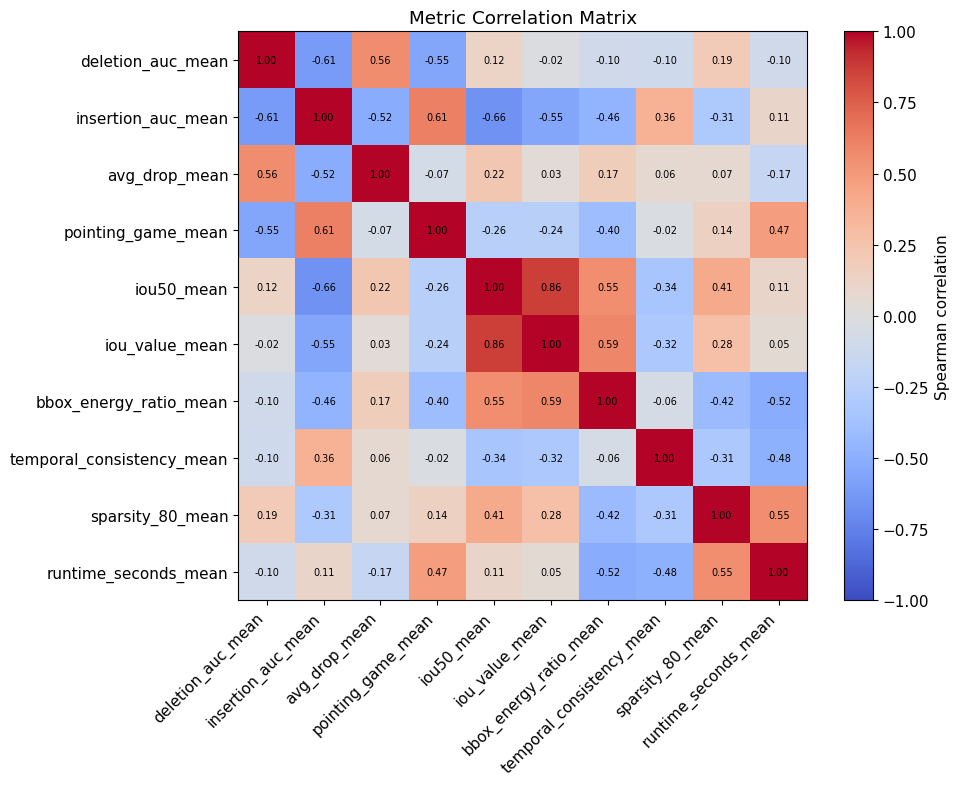

In [9]:
correlation_columns = [f"{metric}_mean" for metric in RANK_METRICS]
corr_df = summary_df[correlation_columns].corr(method="spearman")
corr_df.to_csv(RESULTS_DIR / "metric_correlation_spearman.csv")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_df, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_df.index)), corr_df.index)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Spearman correlation")
ax.set_title("Metric Correlation Matrix")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "metric_correlation_matrix.png", dpi=200)
plt.show()


## Runtime and Metric Plots

These plots are mainly for reading the trade-offs. I keep only a few, because too many plots make the notebook harder to follow.

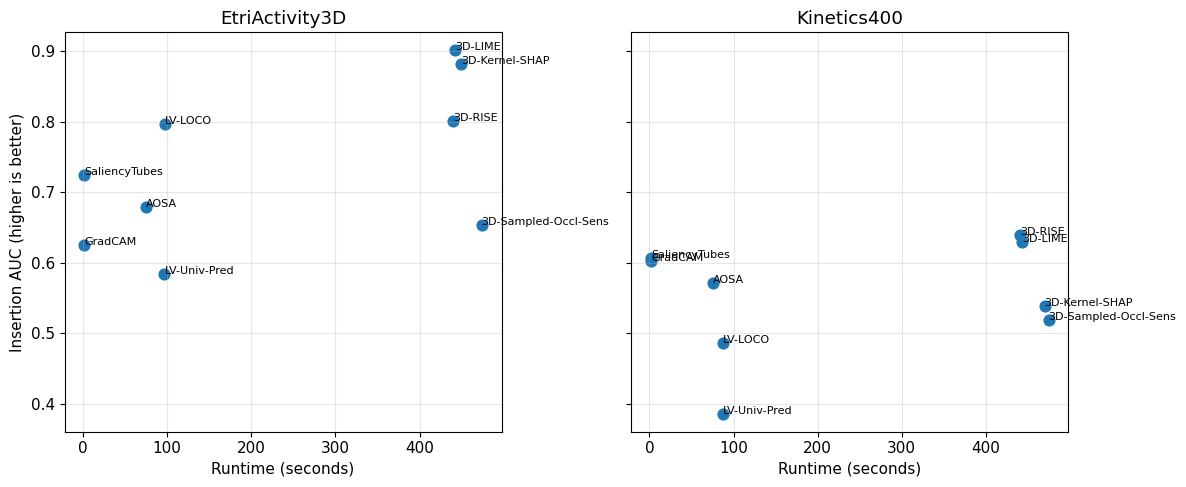

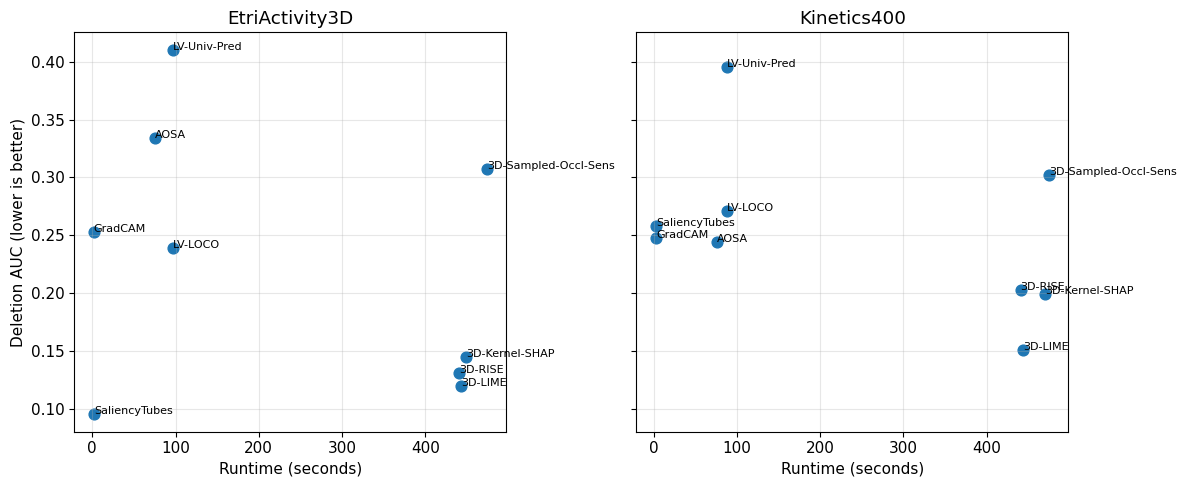

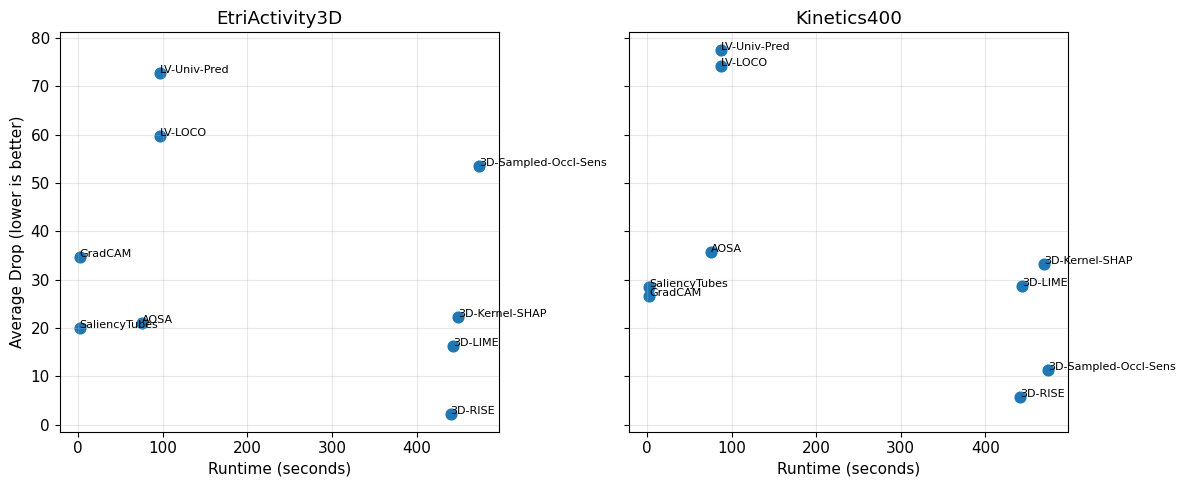

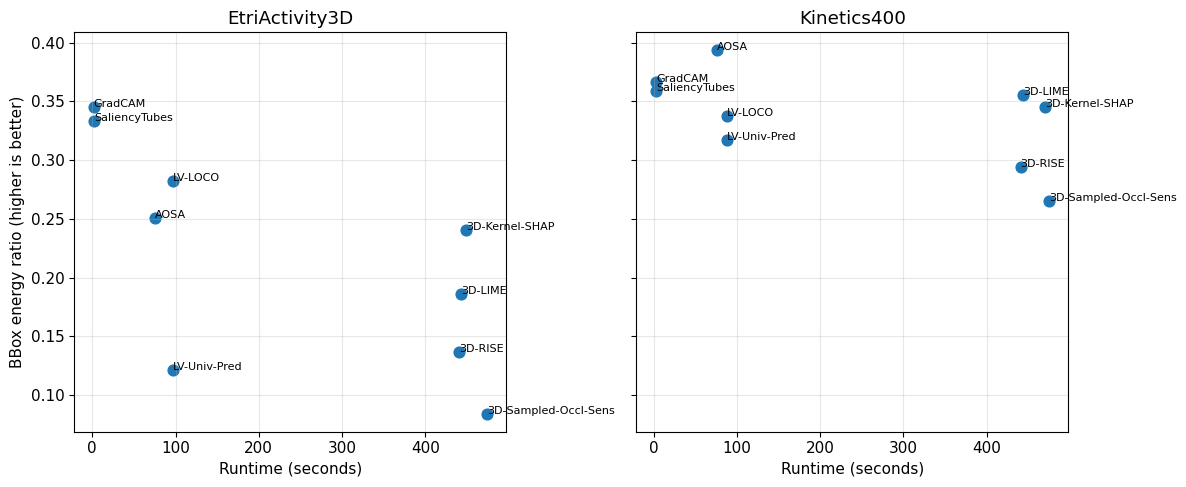

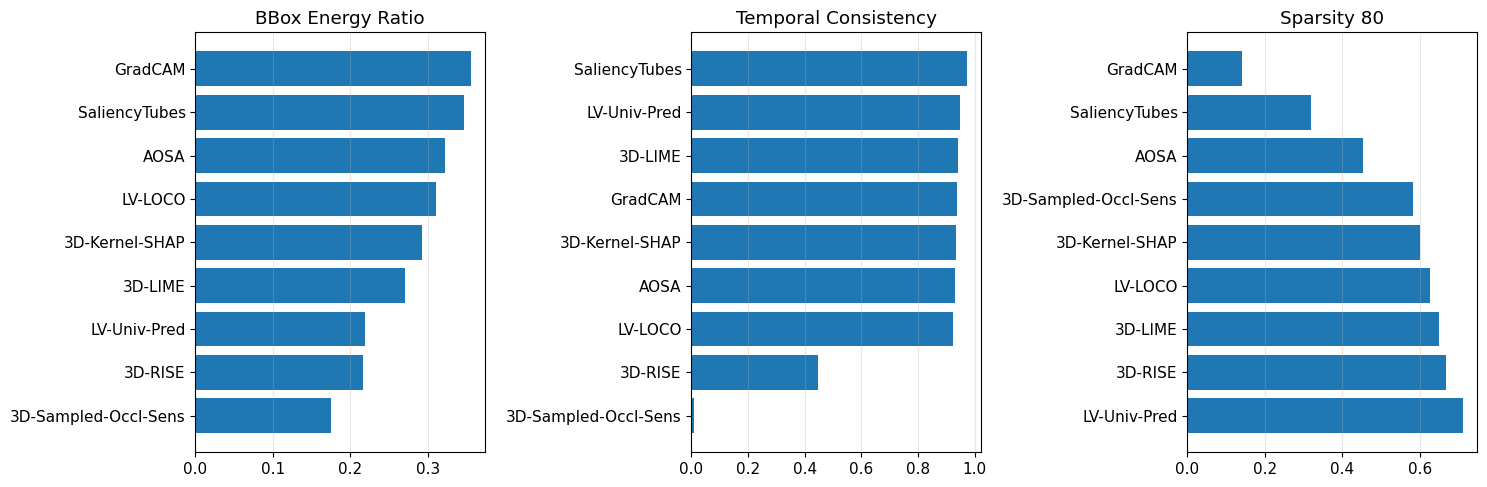

In [10]:
def scatter_runtime_vs(metric, y_label, filename):
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(12, 5), sharey=True)
    if len(DATASETS) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, DATASETS):
        subset = summary_df[summary_df["dataset"] == dataset]
        ax.scatter(subset["runtime_seconds_mean"], subset[f"{metric}_mean"], s=60)

        for _, row in subset.iterrows():
            ax.annotate(row["method_display"], (row["runtime_seconds_mean"], row[f"{metric}_mean"]), fontsize=8)

        ax.set_title(dataset)
        ax.set_xlabel("Runtime (seconds)")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(y_label)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200)
    plt.show()


scatter_runtime_vs("insertion_auc", "Insertion AUC (higher is better)", "runtime_vs_insertion_auc.png")
scatter_runtime_vs("deletion_auc", "Deletion AUC (lower is better)", "runtime_vs_deletion_auc.png")
scatter_runtime_vs("avg_drop", "Average Drop (lower is better)", "runtime_vs_avg_drop.png")
scatter_runtime_vs("bbox_energy_ratio", "BBox energy ratio (higher is better)", "runtime_vs_bbox_energy_ratio.png")

custom_plot_df = (
    summary_df
    .groupby(["method", "method_display"])[[f"{metric}_mean" for metric in CUSTOM_METRICS]]
    .mean()
    .reset_index()
)

custom_titles = {
    "bbox_energy_ratio": "BBox Energy Ratio",
    "temporal_consistency": "Temporal Consistency",
    "sparsity_80": "Sparsity 80",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, CUSTOM_METRICS):
    value_col = f"{metric}_mean"
    ascending = METRIC_DIRECTIONS[metric] == "lower"
    metric_plot_df = custom_plot_df.sort_values(value_col, ascending=ascending)

    ax.barh(metric_plot_df["method_display"], metric_plot_df[value_col])
    ax.invert_yaxis()
    ax.set_title(custom_titles[metric])
    ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "custom_metric_summary.png", dpi=200)
plt.show()


## Ranking Heatmap

This is the compact view I will probably use most when writing the results section.

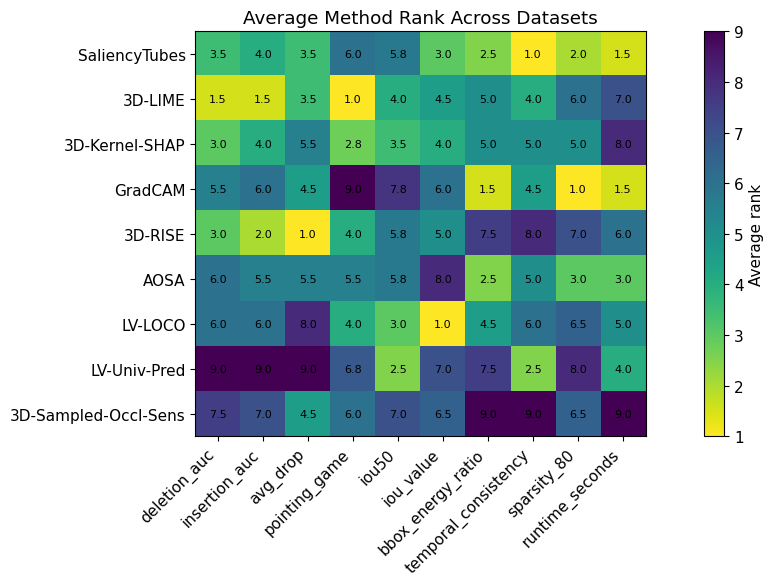

In [11]:
heatmap_df = global_rank.set_index("method_display")[rank_columns]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_df, cmap="viridis_r")
ax.set_xticks(range(len(heatmap_df.columns)), [column.replace("rank_", "") for column in heatmap_df.columns], rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_df.index)), heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(j, i, f"{heatmap_df.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Average rank")
ax.set_title("Average Method Rank Across Datasets")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "global_ranking_heatmap.png", dpi=200)
plt.show()


## Files Generated

Tables saved in `docs/results`:

- `metrics_per_video.csv`
- `custom_metrics_per_video.csv`
- `runtime_per_video.csv`
- `metric_summary_by_dataset.csv`
- `rankings_by_dataset.csv`
- `global_average_rank.csv`
- `metric_correlation_spearman.csv`
- `selected_iou_thresholds.csv`

Figures saved in `docs/figures/metrics-analysis`:

- `metric_correlation_matrix.png`
- `runtime_vs_insertion_auc.png`
- `runtime_vs_deletion_auc.png`
- `runtime_vs_avg_drop.png`
- `runtime_vs_bbox_energy_ratio.png`
- `custom_metric_summary.png`
- `global_ranking_heatmap.png`

## Preliminary Interpretation

This is my current reading of the results for `TANet`, two datasets, 30 videos per dataset, and the 9 explanation methods.

The main thing I need to be careful with is the word "best". After adding my three metrics, `SaliencyTubes` gets the best global average rank, mainly because it is fast, stable over time, and fairly concentrated. That does not mean it wins every type of evaluation.

For the faithfulness metrics, `3D-LIME` is still the strongest method in deletion and insertion. `3D-RISE` is best in Average Drop. For the older localization metrics, `LV-LOCO` is strong in IoU. For the new metrics, `SaliencyTubes` is best in Temporal Consistency and `GradCAM` is best in Sparsity 80. Bounding-box Energy Ratio changes by dataset, with `GradCAM` stronger on ETRI and `AOSA` stronger on Kinetics.

So the result is not one clean winner. The metric changes the conclusion. I think this is useful for the thesis, because it supports the idea that video XAI methods should be compared with several metrics instead of only one.

For now I would describe the contribution as: a multi-metric comparison of 9 video XAI methods, plus three simple extra metrics focused on localization, temporal stability, and concentration.